 # Projeto de Risco de Crédito – Bradebank Solutions
 
 Este notebook reúne todas as etapas do projeto:
 
 1. Importação e Limpeza dos Dados  
 2. Análise Exploratória (EDA) com detalhamento de estatísticas, balanceamento da variável alvo, visualizações univariadas e bivariadas, matriz de correlação e identificação de outliers  
 3. Feature Engineering  
 4. Modelagem Preditiva com comparação de modelos (Regressão Logística, Árvore de Decisão, Random Forest, XGBoost, LightGBM, CatBoost, MLP e AutoML com PyCaret)  
 5. Avaliação dos Modelos (métricas, curva ROC, matriz de confusão)  
 6. Interpretabilidade (SHAP e, opcionalmente, LIME)  
 7. Dashboard Interativo incorporado no Notebook (usando Plotly e ipywidgets)  
 8. Conclusão e próximos passos
 
 _Observação: Os dados analisados são sintéticos (250 clientes) e os padrões encontrados são apenas ilustrativos._


In [1]:
# Importes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import io

# Configuração básica de visualização
sns.set(style="whitegrid")
%matplotlib inline

## 1. Importação e Limpeza dos Dados

 Nesta seção, importamos os dados de várias planilhas do Excel, realizamos o merge com base na coluna `ID_Cliente` e efetuamos os tratamentos:
 - Converter valores negativos para positivos em `Renda_Anual` e `Valor_do_Emprestimo`
 - Definir valores de `Idade` fora do intervalo [18, 100] como NaN
 - Aplicar winsorização para reduzir o impacto de outliers

In [2]:
file_path = 'Dados 3.xlsx'

sheets = pd.read_excel(file_path, sheet_name=None)
print("Planilhas encontradas:", list(sheets.keys()))

dfs = list(sheets.values())

df_merged = dfs[0]
for df_temp in dfs[1:]:
    df_merged = pd.merge(df_merged, df_temp, on='ID_Cliente', how='outer')

Planilhas encontradas: ['Base1', 'Base2', 'Base3']


In [3]:
print("Dimensões do DataFrame integrado:", df_merged.shape)
df_merged.head()

Dimensões do DataFrame integrado: (250, 11)


,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Inadimplencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,Não,60000.0,10000.0,36.0
1,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,Não,100.0,15000.0,48.0
2,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,Não,NaN,12000.0,36.0
3,6,20,F,Casado,Ensino Superior,3,Casa Própria,Sim,90000.0,18000.0,48.0
4,7,42,F,Casado,Ensino Médio,2,Casa Própria,Não,65000.0,14000.0,36.0


In [4]:
df = df_merged.copy()

# Exibir informações gerais e primeiras linhas
print("Info do DataFrame:")
df.info()
print("Primeiras linhas:")
print(df.head())

# Estatísticas descritivas
print("Estatísticas descritivas:")
print(df.describe())

# Valores faltantes por coluna
print("Valores faltantes por coluna:")
print(df.isnull().sum())



Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             250 non-null    int64  
 1   Idade                  250 non-null    int64  
 2   Genero                 248 non-null    object 
 3   Estado_Civil           246 non-null    object 
 4   Escolaridade           248 non-null    object 
 5   Numero_de_Dependentes  250 non-null    int64  
 6   Tipo_de_Residencia     249 non-null    object 
 7   Inadimplencia          250 non-null    object 
 8   Renda_Anual            244 non-null    float64
 9   Valor_do_Emprestimo    246 non-null    float64
 10  Prazo_do_Emprestimo    246 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 21.6+ KB
Primeiras linhas:
   ID_Cliente  Idade Genero Estado_Civil     Escolaridade  \
0           1     35      F       Casado  Ensino Superior 

In [5]:
print("\nRespostas únicas para colunas não numéricas (para análise e futuras operações de one hot encoding):")
colunas_obj = df.select_dtypes(include=['object']).columns
for coluna in colunas_obj:
    respostas_distintas = df[coluna].dropna().unique()
    print(f"\nColuna: {coluna} (Total de respostas: {len(respostas_distintas)})")
    print("Respostas:", respostas_distintas)


Respostas únicas para colunas não numéricas (para análise e futuras operações de one hot encoding):

Coluna: Genero (Total de respostas: 2)
Respostas: ['F' 'M']

Coluna: Estado_Civil (Total de respostas: 3)
Respostas: ['Casado' 'Divorciado' 'Solteiro']

Coluna: Escolaridade (Total de respostas: 4)
Respostas: ['Ensino Superior' 'Pós-Graduação' 'Ensino Médio' 'Casa Própria']

Coluna: Tipo_de_Residencia (Total de respostas: 4)
Respostas: ['Casa Própria' 'Casa Alugada' 'Apartamento Próprio' 'Apartamento Alugado']

Coluna: Inadimplencia (Total de respostas: 2)
Respostas: ['Não' 'Sim']


In [6]:
df['Escolaridade'] = df['Escolaridade'].replace('Casa Própria', np.nan)
print("Substituição realizada: 'Casa Própria' na coluna 'Escolaridade' foi substituída por NaN")


Substituição realizada: 'Casa Própria' na coluna 'Escolaridade' foi substituída por NaN


In [7]:
# Converter valores negativos em 'Renda_Anual' e 'Valor_do_Emprestimo' para positivos
df['Renda_Anual'] = df['Renda_Anual'].abs()
df['Valor_do_Emprestimo'] = df['Valor_do_Emprestimo'].abs()

# Para 'Idade': definir como NaN valores fora do intervalo [18, 100]
df.loc[(df['Idade'] < 18) | (df['Idade'] > 100), 'Idade'] = np.nan
print("Resumo de 'Idade' após tratamento:")
print(df['Idade'].describe())

# Ordenar pelo 'ID_Cliente' e resetar o índice
df.sort_values(by='ID_Cliente', inplace=True)
df.reset_index(drop=True, inplace=True)
print("Exemplo dos 10 primeiros ID_Cliente:")
print(df[['ID_Cliente']].head(10))

Resumo de 'Idade' após tratamento:
count    244.000000
mean      41.073770
std        8.111535
min       20.000000
25%       34.000000
50%       41.000000
75%       48.000000
max       58.000000
Name: Idade, dtype: float64
Exemplo dos 10 primeiros ID_Cliente:
   ID_Cliente
0           1
1           2
2           3
3           4
4           5
5           6
6           7
7           8
8           9
9          10


## 🧼 Tratamento de Outliers com Winsorização

Antes de aplicar os modelos, é essencial tratar valores extremos (outliers) que podem impactar negativamente a performance dos algoritmos de machine learning. Neste projeto, utilizamos a técnica de **winsorização** para reduzir o efeito de outliers em variáveis financeiras como `Renda_Anual` e `Valor_do_Emprestimo`.

A winsorização substitui valores muito baixos ou muito altos por limites definidos com base no intervalo interquartílico (IQR), garantindo que os dados se mantenham em uma faixa mais estável, **sem perder informações importantes**.

A seguir, aplicamos a winsorização com `k = 1.5`, valor tradicionalmente usado para identificar outliers fora da faixa interquartílica estendida. Também ajustamos o tipo da variável `Idade` para `Int64` de forma segura.

Essa etapa melhora a **robustez estatística** dos dados e prepara o conjunto de dados para uma modelagem mais eficiente e confiável.

In [8]:
# Função para winsorização
def winsorize_series(s, k=1.5):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    return s.clip(lower=lower_bound, upper=upper_bound)

# Armazenar os valores originais para comparação
renda_original = df['Renda_Anual'].copy()

# Aplicar winsorização em 'Renda_Anual' e 'Valor_do_Emprestimo'
df['Renda_Anual'] = winsorize_series(df['Renda_Anual'])
df['Valor_do_Emprestimo'] = winsorize_series(df['Valor_do_Emprestimo'])

# Converter 'Idade' para tipo int preservando NaN (usando o tipo Int64)
df['Idade'] = df['Idade'].astype('float64').astype('Int64')

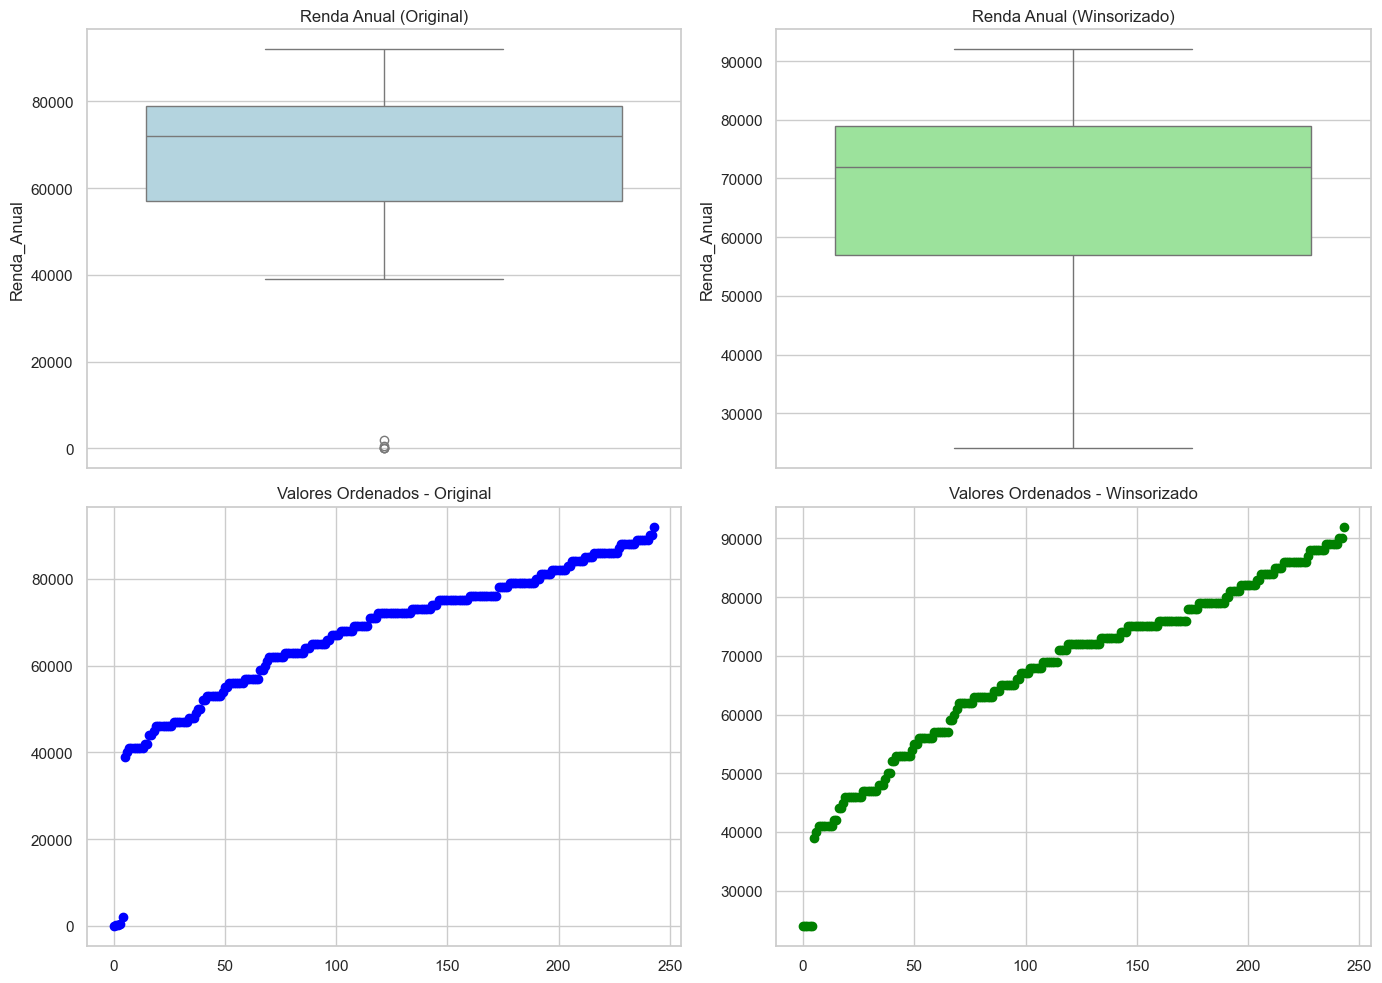

In [9]:
# Visualizações comparativas para Renda_Anual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(y=renda_original, ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Renda Anual (Original)')
sns.boxplot(y=df['Renda_Anual'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Renda Anual (Winsorizado)')
axes[1, 0].plot(np.sort(renda_original.dropna()), marker='o', linestyle='None', color='blue')
axes[1, 0].set_title('Valores Ordenados - Original')
axes[1, 1].plot(np.sort(df['Renda_Anual'].dropna()), marker='o', linestyle='None', color='green')
axes[1, 1].set_title('Valores Ordenados - Winsorizado')
plt.tight_layout()
plt.show()

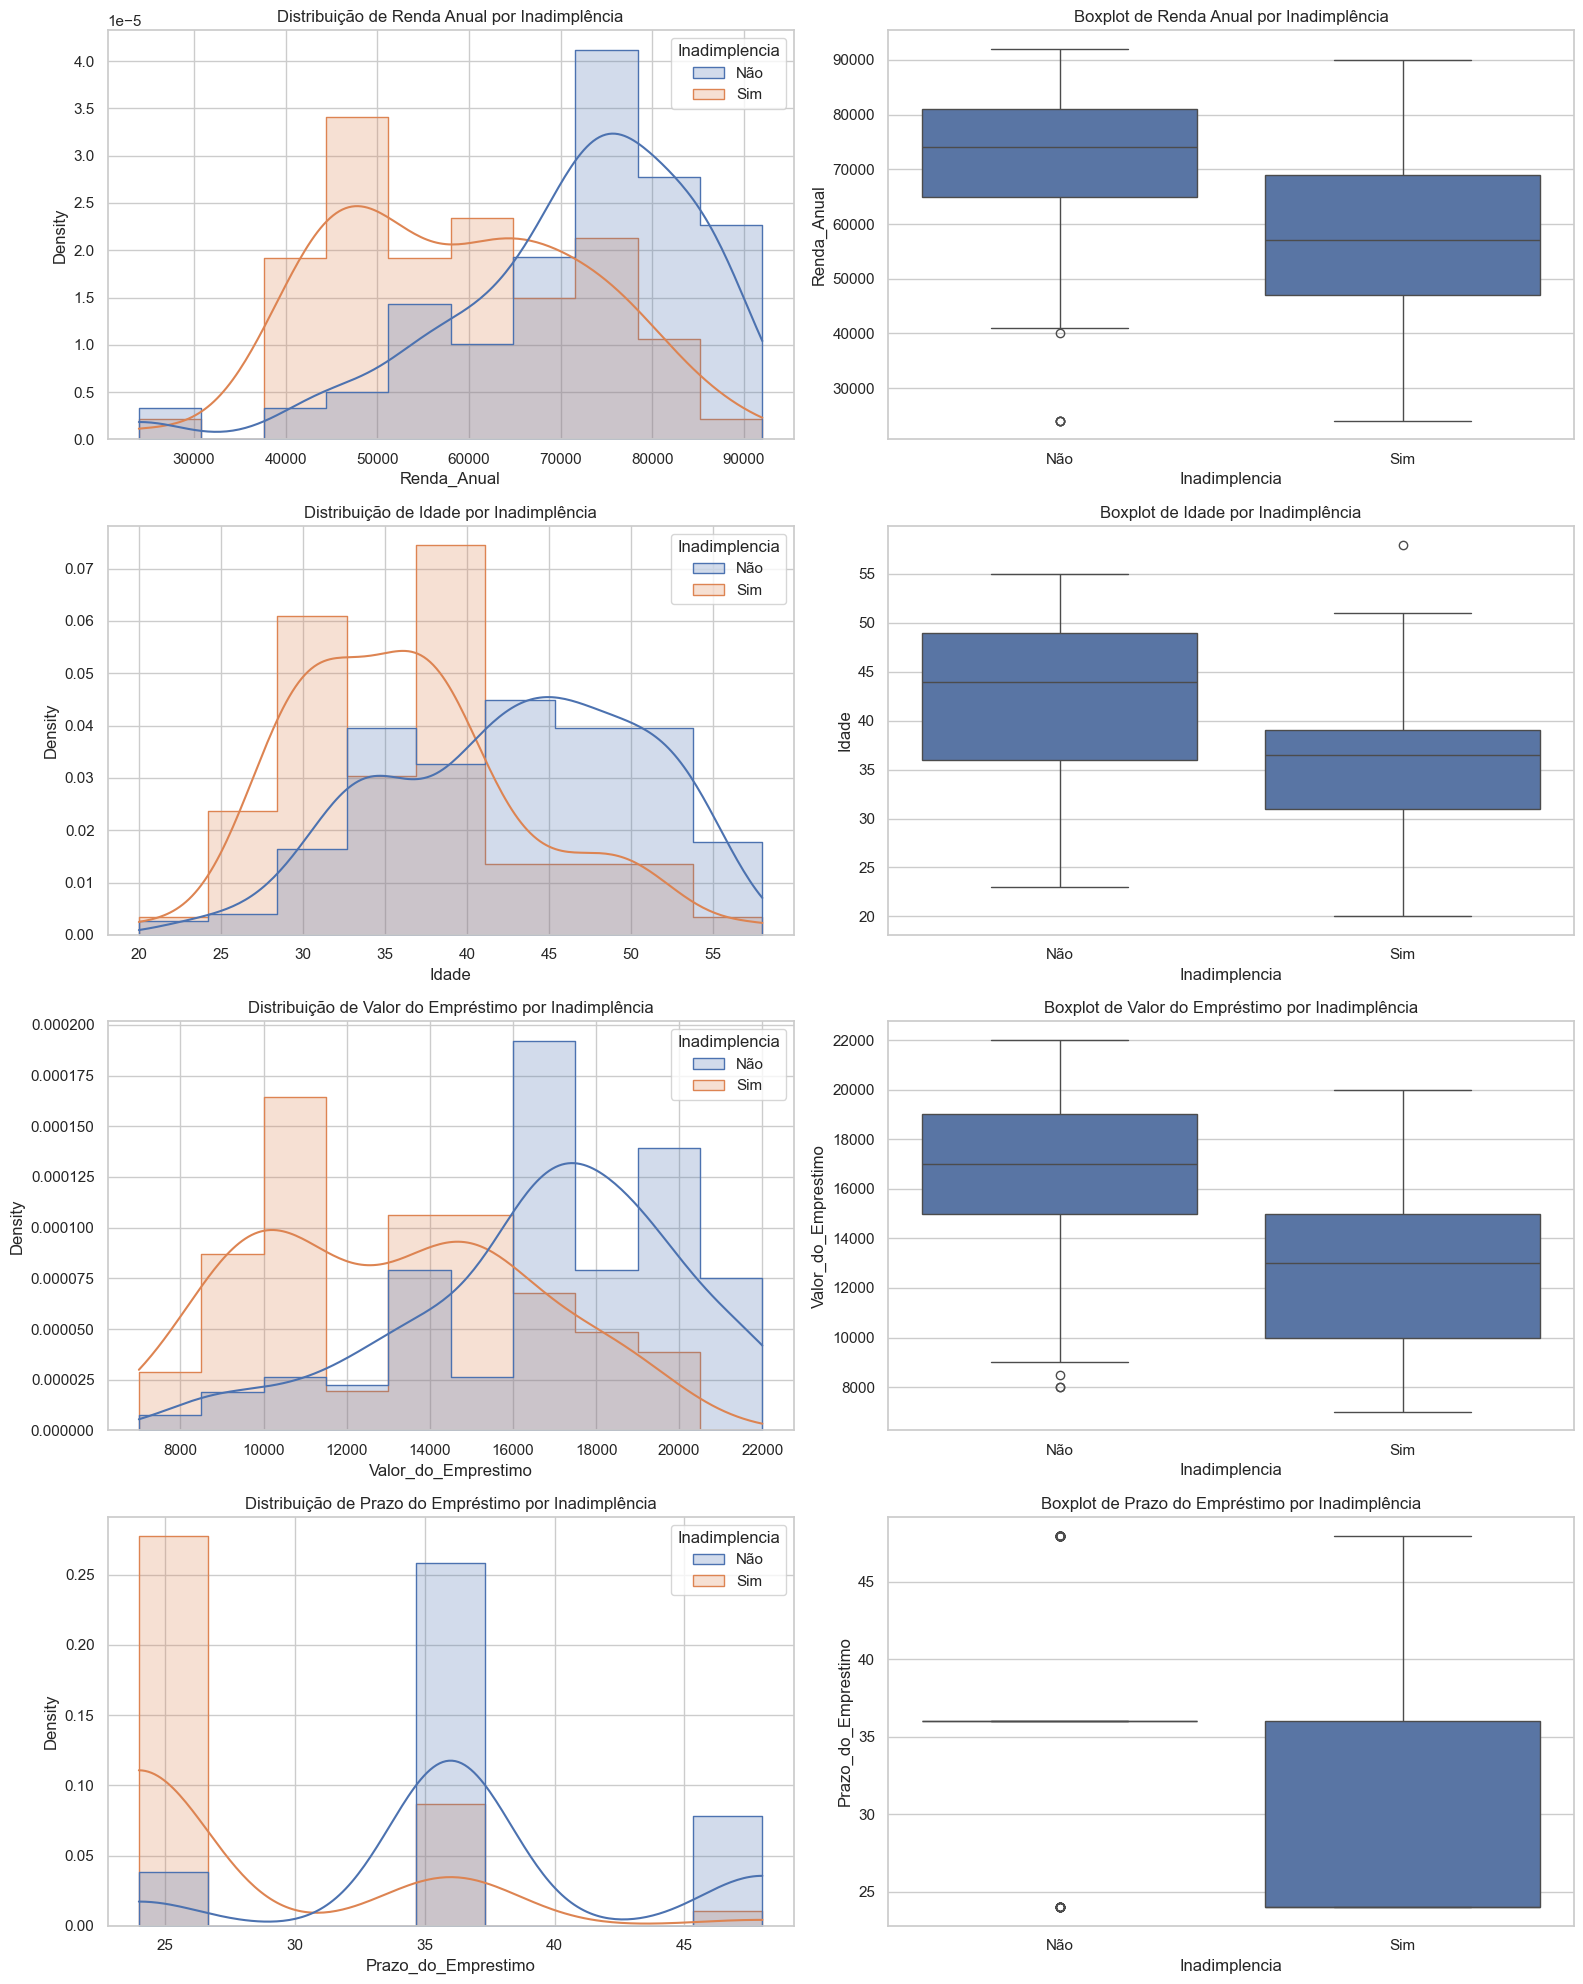

In [10]:
# Visualizações por variável e Inadimplência
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
sns.histplot(data=df, x='Renda_Anual', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribuição de Renda Anual por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Renda_Anual', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot de Renda Anual por Inadimplência')
sns.histplot(data=df, x='Idade', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Idade por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Idade', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot de Idade por Inadimplência')
sns.histplot(data=df, x='Valor_do_Emprestimo', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[2, 0])
axes[2, 0].set_title('Distribuição de Valor do Empréstimo por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Valor_do_Emprestimo', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Boxplot de Valor do Empréstimo por Inadimplência')
sns.histplot(data=df, x='Prazo_do_Emprestimo', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[3, 0])
axes[3, 0].set_title('Distribuição de Prazo do Empréstimo por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Prazo_do_Emprestimo', data=df, ax=axes[3, 1])
axes[3, 1].set_title('Boxplot de Prazo do Empréstimo por Inadimplência')
plt.tight_layout()
plt.show()

In [11]:
# Reordenar as colunas para deixar 'Inadimplencia' como a última coluna
cols = [col for col in df.columns if col != 'Inadimplencia'] + ['Inadimplencia']
df = df[cols]
df

,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Inadimplencia
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,60000.0,10000.0,36.0,Não
1,2,28,F,NaN,Ensino Médio,0,Casa Própria,40000.0,8000.0,24.0,Não
2,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,24000.0,15000.0,48.0,Não
3,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,NaN,12000.0,36.0,Não
4,5,33,F,Casado,Ensino Médio,1,Casa Alugada,50000.0,9000.0,24.0,Sim
...,...,...,...,...,...,...,...,...,...,...,...
245,246,51,M,Solteiro,Ensino Superior,2,Casa Própria,84000.0,18000.0,36.0,Não
246,247,46,F,Casado,Pós-Graduação,3,Apartamento Alugado,76000.0,19000.0,36.0,Não
247,248,41,F,Casado,Ensino Médio,1,Apartamento Alugado,69000.0,17000.0,36.0,Sim
248,249,36,F,Solteiro,Ensino Superior,0,Casa Alugada,62000.0,14000.0,24.0,Sim


# 2. Análise Exploratória (EDA) Detalhada
# 
 Nesta seção, além das visualizações já apresentadas, faremos:
 - Documentação do dicionário de dados (comentários sobre cada coluna)
 - Cálculo das estatísticas resumidas para variáveis numéricas (com `describe()`)
 - Análise do balanceamento da variável alvo (Inadimplencia)
 - Countplots para variáveis categóricas (ex.: Gênero, Estado_Civil)
 - Scatterplot de Renda_Anual vs Valor_do_Emprestimo colorido por Inadimplencia
 - Matriz de correlação (com heatmap)

In [12]:
# Dicionário de Dados (comentários/documentação – ajustado conforme conhecimento do negócio)
print("""
Dicionário de Dados:
- ID_Cliente: Identificador único do cliente.
- Idade: Idade do cliente (em anos). Valores fora de 18-100 foram removidos.
- Gênero: Masculino/Feminino.
- Estado_Civil: Ex: Solteiro, Casado, Divorciado, Viúvo.
- Escolaridade: Nível educacional (Fundamental, Médio, Superior, Pós-graduação).
- Renda_Anual: Renda anual do cliente (R$). Valores outliers foram winsorizados.
- Número_de_Dependentes: Número de dependentes.
- Tipo_de_Residência: Ex: Própria, Alugada, Financiada.
- Valor_do_Emprestimo: Valor do empréstimo solicitado (R$). Outliers controlados.
- Prazo_do_Emprestimo: Prazo do empréstimo (em meses).
- Inadimplencia: Target - 'Sim' ou 'Não'.
""")

# Estatísticas resumidas
print("Estatísticas resumidas (variáveis numéricas):")
print(df.describe())

# Balanceamento da variável alvo
print("Distribuição da variável Inadimplencia:")
print(df['Inadimplencia'].value_counts(normalize=True)*100)


Dicionário de Dados:
- ID_Cliente: Identificador único do cliente.
- Idade: Idade do cliente (em anos). Valores fora de 18-100 foram removidos.
- Gênero: Masculino/Feminino.
- Estado_Civil: Ex: Solteiro, Casado, Divorciado, Viúvo.
- Escolaridade: Nível educacional (Fundamental, Médio, Superior, Pós-graduação).
- Renda_Anual: Renda anual do cliente (R$). Valores outliers foram winsorizados.
- Número_de_Dependentes: Número de dependentes.
- Tipo_de_Residência: Ex: Própria, Alugada, Financiada.
- Valor_do_Emprestimo: Valor do empréstimo solicitado (R$). Outliers controlados.
- Prazo_do_Emprestimo: Prazo do empréstimo (em meses).
- Inadimplencia: Target - 'Sim' ou 'Não'.

Estatísticas resumidas (variáveis numéricas):
       ID_Cliente     Idade  Numero_de_Dependentes   Renda_Anual  \
count  250.000000     244.0             250.000000    244.000000   
mean   125.500000  41.07377               1.400000  67721.311475   
std     72.312977  8.111535               1.082908  14988.205127   
min 

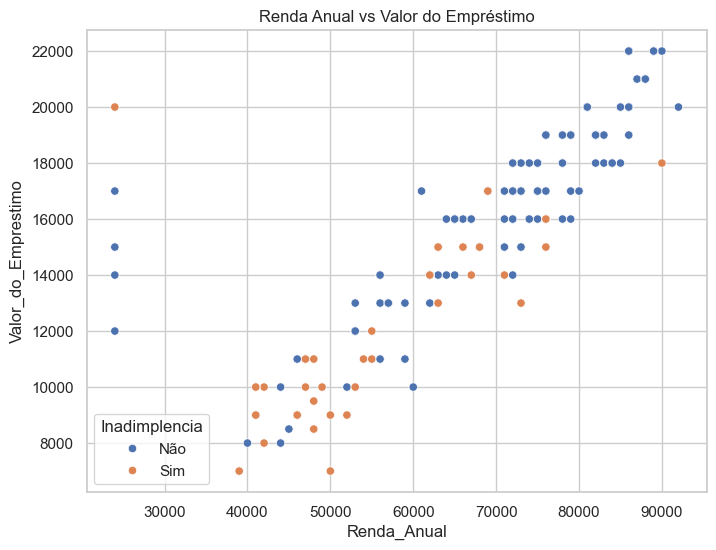

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Renda_Anual', y='Valor_do_Emprestimo', hue='Inadimplencia')
plt.title('Renda Anual vs Valor do Empréstimo')
plt.show()

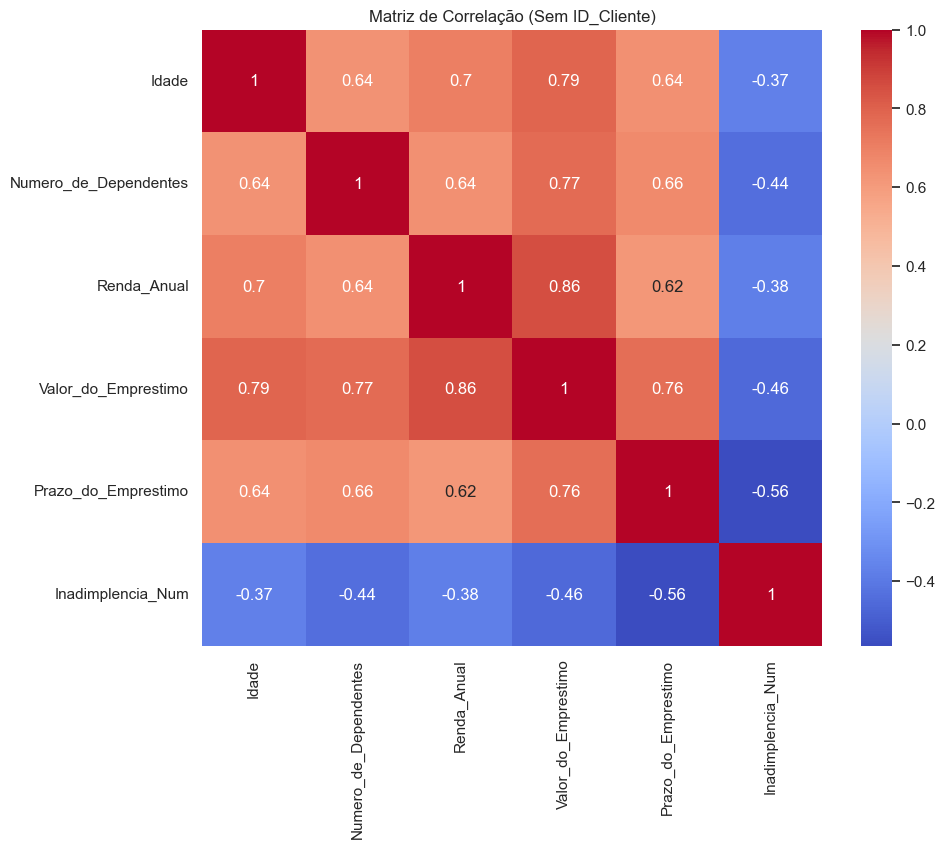

In [14]:
df_corr = df.copy()

# Converter Inadimplencia para 0/1
df_corr['Inadimplencia_Num'] = df_corr['Inadimplencia'].apply(lambda x: 1 if x=='Sim' else 0)

# Remover a coluna ID_Cliente antes de calcular a correlação
df_corr.drop(columns=['ID_Cliente'], inplace=True)

# Calcular a matriz de correlação apenas com colunas numéricas
corr_matrix = df_corr.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação (Sem ID_Cliente)')
plt.show()


## Explodindo variaveis categoricas com one-hot enconding

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1) Copiar o DataFrame original
df_encoded_allcats = df.copy()

# 2) Remover ID_Cliente (se existir) e converter Inadimplencia em numérico
df_encoded_allcats.drop(columns=['ID_Cliente'], errors='ignore', inplace=True)
df_encoded_allcats['Inadimplencia_Num'] = df_encoded_allcats['Inadimplencia'].map({'Sim': 1, 'Não': 0})
df_encoded_allcats.drop(columns=['Inadimplencia'], inplace=True)

# 3) Identificar colunas categóricas e criar dummies
cat_cols = df_encoded_allcats.select_dtypes(include=['object']).columns
df_encoded_allcats = pd.get_dummies(df_encoded_allcats, columns=cat_cols, drop_first=False)

print(df_encoded_allcats.columns)



Index(['Idade', 'Numero_de_Dependentes', 'Renda_Anual', 'Valor_do_Emprestimo',
       'Prazo_do_Emprestimo', 'Inadimplencia_Num', 'Genero_F', 'Genero_M',
       'Estado_Civil_Casado', 'Estado_Civil_Divorciado',
       'Estado_Civil_Solteiro', 'Escolaridade_Ensino Médio',
       'Escolaridade_Ensino Superior', 'Escolaridade_Pós-Graduação',
       'Tipo_de_Residencia_Apartamento Alugado',
       'Tipo_de_Residencia_Apartamento Próprio',
       'Tipo_de_Residencia_Casa Alugada', 'Tipo_de_Residencia_Casa Própria'],
      dtype='object')


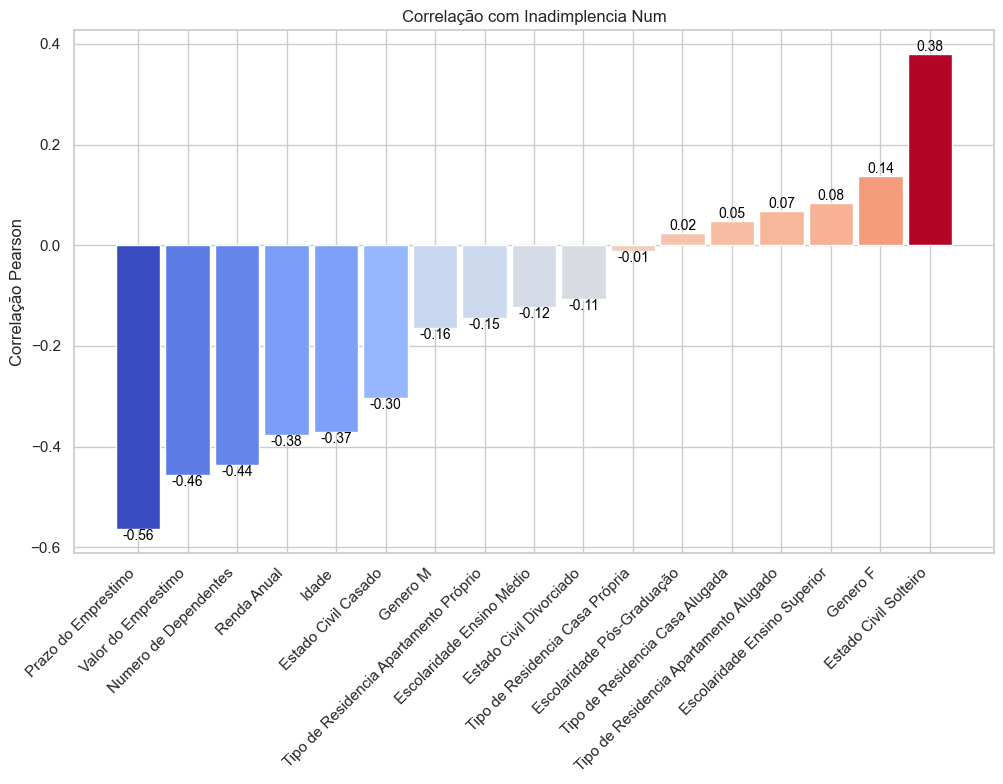

In [16]:
corr_matrix_allcats = df_encoded_allcats.corr(method='pearson')

# Extrair as correlações com a coluna Inadimplencia_Num, exceto ela mesma
corr_with_inad_allcats = corr_matrix_allcats['Inadimplencia_Num'].drop('Inadimplencia_Num')
corr_with_inad_allcats = corr_with_inad_allcats.sort_values(ascending=True)
# Substituir os underscores por espaços nos nomes das variáveis
corr_with_inad_allcats.index = corr_with_inad_allcats.index.str.replace('_', ' ')

# Criar gráfico de barras verticais em vez de horizontais
fig, ax = plt.subplots(figsize=(len(corr_with_inad_allcats)*0.6, 8))

cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=corr_with_inad_allcats.min(), 
                           vmax=corr_with_inad_allcats.max())

# Usar bar em vez de barh para barras verticais
bars = ax.bar(
    corr_with_inad_allcats.index, 
    corr_with_inad_allcats.values, 
    width=0.9,  # Aumentar a largura das barras
    color=[cmap(norm(val)) for val in corr_with_inad_allcats.values]
)

# Adicionar o valor da correlação em cada barra (acima da barra)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.2f}', 
            ha='center',
            va='bottom' if height >= 0 else 'top',
            color='black', fontsize=10)

# Rotacionar os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

ax.set_ylabel('Correlação Pearson')
ax.set_title('Correlação com Inadimplencia Num')
plt.tight_layout()
plt.show()

### Análise Estatística das Variáveis Explicativas

Nesta etapa, aplicamos diferentes testes estatísticos para avaliar a relevância de cada variável na previsão da inadimplência. Foram calculadas as seguintes métricas para cada feature:

- **Chi² Score**: Testa a independência entre cada variável e o target. Quanto maior o valor, mais dependente (relevante) a variável é para explicar o target.
- **Mutual Information**: Mede a quantidade de informação compartilhada entre a variável e o target. É útil para detectar relações não lineares.
- **ANOVA F-Score**: Verifica se a média da variável difere significativamente entre as classes da variável alvo.
- **Correlação de Pearson**: Mede a relação linear entre a variável e a inadimplência. Valores negativos indicam relação inversa (quanto maior a variável, menor a chance de inadimplência).

Todas as variáveis foram normalizadas para uso adequado no teste qui-quadrado, e valores ausentes foram tratados com a média da respectiva coluna.

In [51]:
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Separar features e target
X = df_encoded_allcats.drop(columns=['Inadimplencia_Num'])
y = df_encoded_allcats['Inadimplencia_Num']

# Converter todas as colunas para float (para evitar erro com Int64)
X = X.astype('float')

# Substituir NaNs pela média de cada coluna
X_filled = X.fillna(X.mean())

# Normalizar os dados para o chi² (que só aceita valores positivos)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_filled), columns=X.columns)

# Calcular métricas
chi2_scores, _ = chi2(X_scaled, y)
mutual_info = mutual_info_classif(X_scaled, y, discrete_features='auto')
f_scores, _ = f_classif(X_scaled, y)

# Corrigir correlação com os NaNs tratados
corr_values = X_filled.copy()
corr_values['Inadimplencia_Num'] = y
corr_with_inad = corr_values.corr()['Inadimplencia_Num'].drop('Inadimplencia_Num')

# Montar DataFrame com os resultados
feature_analysis = pd.DataFrame({
    'Feature': X.columns,
    'Chi² Score': chi2_scores,
    'Mutual Information': mutual_info,
    'ANOVA F-Score': f_scores,
    'Pearson Corr': corr_with_inad.values
}).sort_values(by='Mutual Information', ascending=False)

# Exibir com formatação
display(feature_analysis.style.background_gradient(cmap='coolwarm', axis=0))


,Feature,Chi² Score,Mutual Information,ANOVA F-Score,Pearson Corr
4,Prazo_do_Emprestimo,18.610573,0.169168,113.106201,-0.559662
2,Renda_Anual,2.555210,0.159665,40.091635,-0.373045
0,Idade,2.733686,0.135251,39.342493,-0.370025
3,Valor_do_Emprestimo,5.261718,0.129800,64.266795,-0.453660
1,Numero_de_Dependentes,13.270030,0.123500,58.502158,-0.436887
7,Estado_Civil_Casado,12.456767,0.100520,25.005645,-0.302645
6,Genero_M,4.017857,0.083588,6.825688,-0.163663
5,Genero_F,1.915541,0.077000,4.746532,0.137039
14,Tipo_de_Residencia_Apartamento Próprio,4.872180,0.052312,5.343441,-0.145230
13,Tipo_de_Residencia_Apartamento Alugado,0.888889,0.024541,1.184478,0.068945


### Interpretação dos Resultados

A análise mostra que:

- **Prazo do Empréstimo** se destaca em todas as métricas, sendo a variável mais informativa e fortemente correlacionada com a inadimplência.
- **Estado Civil Solteiro**, apesar de apresentar baixa relevância em Mutual Information, teve o maior valor de **Chi² Score** e uma **correlação positiva significativa**, indicando que estar solteiro pode estar relacionado ao aumento da inadimplência.
- **Renda Anual**, **Valor do Empréstimo** e **Número de Dependentes** também apresentam bons resultados, com valores expressivos nas quatro métricas.
- Variáveis como **Tipo de Residência** e **Escolaridade** possuem menor impacto individual, mas ainda podem contribuir em interações com outras features no modelo.

Essas evidências reforçam que o modelo está alinhado com a análise estatística, validando as variáveis mais importantes observadas no SHAP e na correlação.

Colunas disponíveis em df_encoded_allcats:
['Idade', 'Numero_de_Dependentes', 'Renda_Anual', 'Valor_do_Emprestimo', 'Prazo_do_Emprestimo', 'Inadimplencia_Num', 'Genero_F', 'Genero_M', 'Estado_Civil_Casado', 'Estado_Civil_Divorciado', 'Estado_Civil_Solteiro', 'Escolaridade_Ensino Médio', 'Escolaridade_Ensino Superior', 'Escolaridade_Pós-Graduação', 'Tipo_de_Residencia_Apartamento Alugado', 'Tipo_de_Residencia_Apartamento Próprio', 'Tipo_de_Residencia_Casa Alugada', 'Tipo_de_Residencia_Casa Própria']


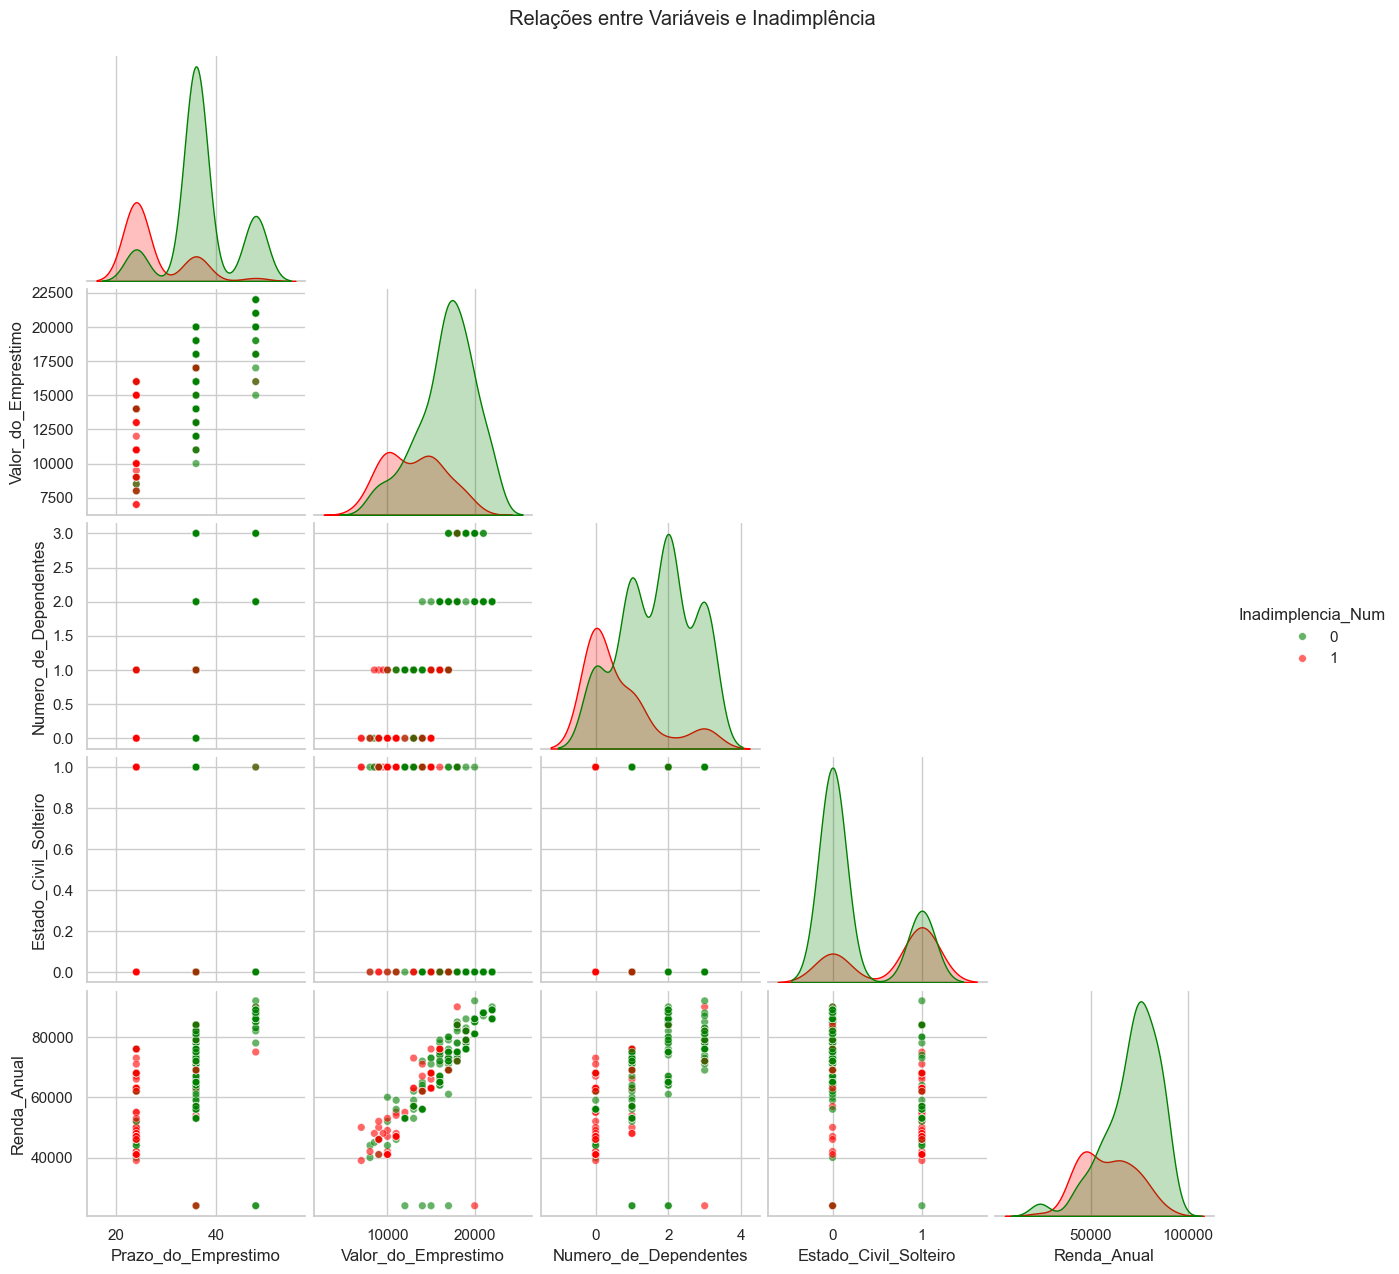

In [17]:
# 1. Primeiro, verifique os nomes reais das colunas no DataFrame codificado:
print("Colunas disponíveis em df_encoded_allcats:")
print(df_encoded_allcats.columns.tolist())

# 2. Corrija a seleção das features top usando os nomes originais (com underscores):
top_features_corrigido = [
    'Prazo_do_Emprestimo', 
    'Valor_do_Emprestimo',
    'Numero_de_Dependentes',
    'Estado_Civil_Solteiro',
    'Renda_Anual',
    'Inadimplencia_Num'
]

# 3. Filtre o DataFrame com os nomes corretos:
df_pairplot = df_encoded_allcats[top_features_corrigido]

# 4. Crie o pairplot (agora com os nomes corretos):
sns.pairplot(
    data=df_pairplot,
    hue='Inadimplencia_Num',
    palette={0: 'green', 1: 'red'},
    corner=True,
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Relações entre Variáveis e Inadimplência', y=1.02)
plt.show()

# 3. Feature Engineering

Nesta etapa, criaremos uma variavel que pode ser util para as analises dos modelos

In [18]:
df['Comprometimento_Mensal'] = (df['Valor_do_Emprestimo'] / df['Prazo_do_Emprestimo']) / (df['Renda_Anual']/12)
df

,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Inadimplencia,Comprometimento_Mensal
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,60000.0,10000.0,36.0,Não,0.055556
1,2,28,F,NaN,Ensino Médio,0,Casa Própria,40000.0,8000.0,24.0,Não,0.100000
2,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,24000.0,15000.0,48.0,Não,0.156250
3,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,NaN,12000.0,36.0,Não,NaN
4,5,33,F,Casado,Ensino Médio,1,Casa Alugada,50000.0,9000.0,24.0,Sim,0.090000
...,...,...,...,...,...,...,...,...,...,...,...,...
245,246,51,M,Solteiro,Ensino Superior,2,Casa Própria,84000.0,18000.0,36.0,Não,0.071429
246,247,46,F,Casado,Pós-Graduação,3,Apartamento Alugado,76000.0,19000.0,36.0,Não,0.083333
247,248,41,F,Casado,Ensino Médio,1,Apartamento Alugado,69000.0,17000.0,36.0,Sim,0.082126
248,249,36,F,Solteiro,Ensino Superior,0,Casa Alugada,62000.0,14000.0,24.0,Sim,0.112903


 ## 4. Modelagem Preditiva com PyCaret - Comparação de Múltiplos Modelos

Nesta etapa, vamos treinar e comparar individualmente os seguintes modelos:

- **Modelos Clássicos:** Regressão Logística (`lr`), Árvore de Decisão (`dt`), Random Forest (`rf`)
- **Modelos de Boosting:** XGBoost (`xgboost`), LightGBM (`lightgbm`), CatBoost (`catboost`)
- **Rede Neural (MLP):** `mlp`
 
 Para cada modelo, criamos, afinamos, finalizamos e geramos a avaliação (curva ROC e matriz de confusão).

In [19]:
from pycaret.classification import setup

exp_setup = setup(
    data=df,
    target='Inadimplencia',
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    train_size=0.8,
    fold=10,
    data_split_stratify=True,
    ignore_features=['ID_Cliente'],
    categorical_features=['Genero', 'Estado_Civil', 'Escolaridade', 'Tipo_de_Residencia'],
    use_gpu=True,                       
    verbose=True
)


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2060 SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves th

,Description,Value
0,Session id,42
1,Target,Inadimplencia
2,Target type,Binary
3,Target mapping,"Não: 0, Sim: 1"
4,Original data shape,"(250, 12)"
5,Transformed data shape,"(338, 18)"
6,Transformed train set shape,"(288, 18)"
7,Transformed test set shape,"(50, 18)"
8,Ignore features,1
9,Numeric features,6


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2060 SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves th

In [20]:
from pycaret.classification import get_config
import pandas as pd

# Obter o pipeline final criado pelo PyCaret
pipeline = get_config('pipeline')

# Aplicar a pipeline ao DataFrame original
df_transformed_array = pipeline.transform(df)

# Se for um numpy array, convertemos para DataFrame
# As colunas podem ser obtidas de 'X_train_transformed' ou via pipeline steps
X_train_transformed = get_config('X_train_transformed')
df_transformed = pd.DataFrame(df_transformed_array, columns=X_train_transformed.columns)

# Visualizar as primeiras linhas do DF transformado
df_transformed.head()

,Idade,Genero,Estado_Civil_Casado,Estado_Civil_Solteiro,Estado_Civil_Divorciado,Escolaridade_Ensino Médio,Escolaridade_Pós-Graduação,Escolaridade_Ensino Superior,Numero_de_Dependentes,Tipo_de_Residencia_Casa Própria,Tipo_de_Residencia_Apartamento Próprio,Tipo_de_Residencia_Apartamento Alugado,Tipo_de_Residencia_Casa Alugada,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Comprometimento_Mensal
0,-0.585883,-0.770479,1.300862,-0.953733,-0.437325,-0.790403,-0.664985,1.441890,-0.117986,1.035136,-0.258476,-0.652569,-0.438993,-0.256750,-1.310937,0.504119,-1.253786
1,-1.526409,-0.770479,1.300862,-0.953733,-0.437325,1.365009,-0.664985,-0.760275,-1.098743,1.035136,-0.258476,-0.652569,-0.438993,-1.591062,-1.865329,-1.098704,0.274320
2,0.757726,-0.770479,1.300862,-0.953733,-0.437325,-0.790403,1.643556,-0.760275,0.862770,-1.086294,-0.258476,-0.652569,2.549348,-2.658511,0.075041,2.106941,2.208328
3,0.085921,-0.770479,-0.826656,-0.953733,2.398552,-0.790403,-0.664985,1.441890,-1.098743,1.035136,-0.258476,-0.652569,-0.438993,0.189969,-0.756546,0.504119,-0.196207
4,-0.854604,-0.770479,1.300862,-0.953733,-0.437325,1.365009,-0.664985,-0.760275,-0.117986,-1.086294,-0.258476,-0.652569,2.549348,-0.923906,-1.588133,-1.098704,-0.069504


### Pós-Pipeline de Pré-processamento

Após aplicar o pipeline, os dados passaram por diversas transformações essenciais:

- **Imputação:** Valores faltantes foram preenchidos com a média para variáveis numéricas e com a moda para categóricas.
- **Encoding e Normalização:** As variáveis categóricas foram transformadas via one-hot encoding e, em seguida, normalizadas usando z-score. Por isso, os valores não aparecem mais como 0 ou 1, mas como números contínuos padronizados.
- **Balanceamento:** Foi utilizado o SMOTE para balancear a classe alvo, aumentando o número de amostras de 250 para 338.
- **Target Mapping:** A variável alvo "Inadimplencia" foi mapeada para 0 (Não) e 1 (Sim).

Como resultado, o conjunto final possui 18 colunas com dados transformados de forma consistente para alimentar os modelos de machine learning.


In [21]:
from pycaret.classification import create_model, tune_model, finalize_model, predict_model


# Definir os modelos e seus respectivos identificadores
model_ids = ['lr', 'dt', 'rf', 'xgboost', 'lightgbm', 'catboost', 'mlp']
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'XGBoost', 'LightGBM', 'CatBoost', 'MLP']

models_dict = {}
predictions_dict = {}

print("Treinando e avaliando os modelos com novas features e ajustes:")

for mid, name in zip(model_ids, model_names):
    print("\n==============================")
    print("Treinando modelo:", name)
    
    model = create_model(mid)
    tuned = tune_model(model)
    final = finalize_model(tuned)
    
    models_dict[name] = final
    pred_holdout = predict_model(final)
    predictions_dict[name] = pred_holdout
    
    print("Previsões (head) para", name)
    display(pred_holdout.head())


Treinando e avaliando os modelos com novas features e ajustes:

Treinando modelo: Logistic Regression


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7000,0.6667,0.7000,0.7418,0.7143,0.2941,0.3026
1,0.7000,0.7200,0.7000,0.7418,0.7143,0.2941,0.3026
2,0.7000,0.5200,0.7000,0.7000,0.7000,0.2000,0.2000
3,0.8500,0.8400,0.8500,0.8631,0.8542,0.6250,0.6299
4,0.8500,0.9524,0.8500,0.8467,0.8458,0.6250,0.6299
5,0.8500,0.8690,0.8500,0.8467,0.8458,0.6250,0.6299
6,0.8500,0.9643,0.8500,0.8604,0.8530,0.6591,0.6634
7,0.8000,0.8214,0.8000,0.8292,0.8066,0.5652,0.5791
8,0.8000,0.8690,0.8000,0.8292,0.8066,0.5652,0.5791


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.6667,0.7500,0.7679,0.7571,0.3750,0.3780
1,0.7000,0.7200,0.7000,0.7418,0.7143,0.2941,0.3026
2,0.6500,0.5467,0.6500,0.6726,0.6599,0.1250,0.1260
3,0.8500,0.8267,0.8500,0.8631,0.8542,0.6250,0.6299
4,0.8500,0.9048,0.8500,0.8467,0.8458,0.6250,0.6299
5,0.8500,0.9167,0.8500,0.8467,0.8458,0.6250,0.6299
6,0.9000,0.9643,0.9000,0.9000,0.9000,0.7619,0.7619
7,0.8000,0.8095,0.8000,0.8292,0.8066,0.5652,0.5791
8,0.8000,0.8690,0.8000,0.8292,0.8066,0.5652,0.5791


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8600,0.8750,0.8600,0.8636,0.8614,0.6602,0.6610


...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.6933,0.7500,0.7679,0.7571,0.3750,0.3780
1,0.7500,0.7200,0.7500,0.8125,0.7650,0.4444,0.4714
2,0.7000,0.5333,0.7000,0.7000,0.7000,0.2000,0.2000
3,0.8500,0.8267,0.8500,0.8631,0.8542,0.6250,0.6299
4,0.8500,0.9167,0.8500,0.8467,0.8458,0.6250,0.6299
5,0.8500,0.9048,0.8500,0.8604,0.8530,0.6591,0.6634
6,0.9000,0.9643,0.9000,0.9250,0.9033,0.7826,0.8018
7,0.8000,0.8095,0.8000,0.8292,0.8066,0.5652,0.5791
8,0.8000,0.8810,0.8000,0.8292,0.8066,0.5652,0.5791


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,MLP Classifier,0.8600,0.9008,0.8600,0.8636,0.8614,0.6602,0.6610


Previsões (head) para MLP


,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Comprometimento_Mensal,Inadimplencia,prediction_label,prediction_score
178,33,F,Solteiro,Ensino Médio,0,Casa Própria,56000.0,14000.0,36.0,0.083333,Não,Não,0.5238
206,28,F,Solteiro,Ensino Superior,0,Casa Própria,41000.0,10000.0,24.0,0.121951,Sim,Sim,0.9356
71,49,F,Solteiro,Pós-Graduação,2,Apartamento Alugado,80000.0,17000.0,36.0,0.070833,Não,Não,0.5848
152,28,F,Solteiro,Ensino Superior,0,Casa Própria,41000.0,10000.0,24.0,0.121951,Sim,Sim,0.9356
148,48,F,Casado,Pós-Graduação,3,Casa Própria,79000.0,19000.0,36.0,0.080169,Não,Não,0.7758


## 5. Avaliação dos Modelos
 
 Nesta etapa, vamos consolidar e visualizar as métricas dos modelos e, em seguida,
 gerar gráficos de desempenho para o modelo final selecionado. 
 O código a seguir extrai as métricas do PyCaret e plota a curva ROC e a matriz de confusão do último modelo treinado.

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score

X_test = get_config('X_test_transformed')
y_test = get_config('y_test_transformed')

metrics = []

for name, model in models_dict.items():
    final_estimator = model.steps[-1][1]
    y_pred = final_estimator.predict(X_test)
    y_prob = final_estimator.predict_proba(X_test)[:, 1]
    
    metrics.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

import pandas as pd
metrics_df = pd.DataFrame(metrics).sort_values('AUC', ascending=False).reset_index(drop=True)
display(metrics_df)


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


,Modelo,Accuracy,AUC,Recall,Precision,F1
0,XGBoost,0.90,0.960317,0.857143,0.800000,0.827586
1,CatBoost,0.90,0.926587,0.785714,0.846154,0.814815
2,MLP,0.86,0.900794,0.785714,0.733333,0.758621
3,Logistic Regression,0.86,0.875000,0.785714,0.733333,0.758621
4,Decision Tree,0.90,0.865079,0.785714,0.846154,0.814815
5,Random Forest,0.90,0.865079,0.785714,0.846154,0.814815
6,LightGBM,0.90,0.831349,0.785714,0.846154,0.814815


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


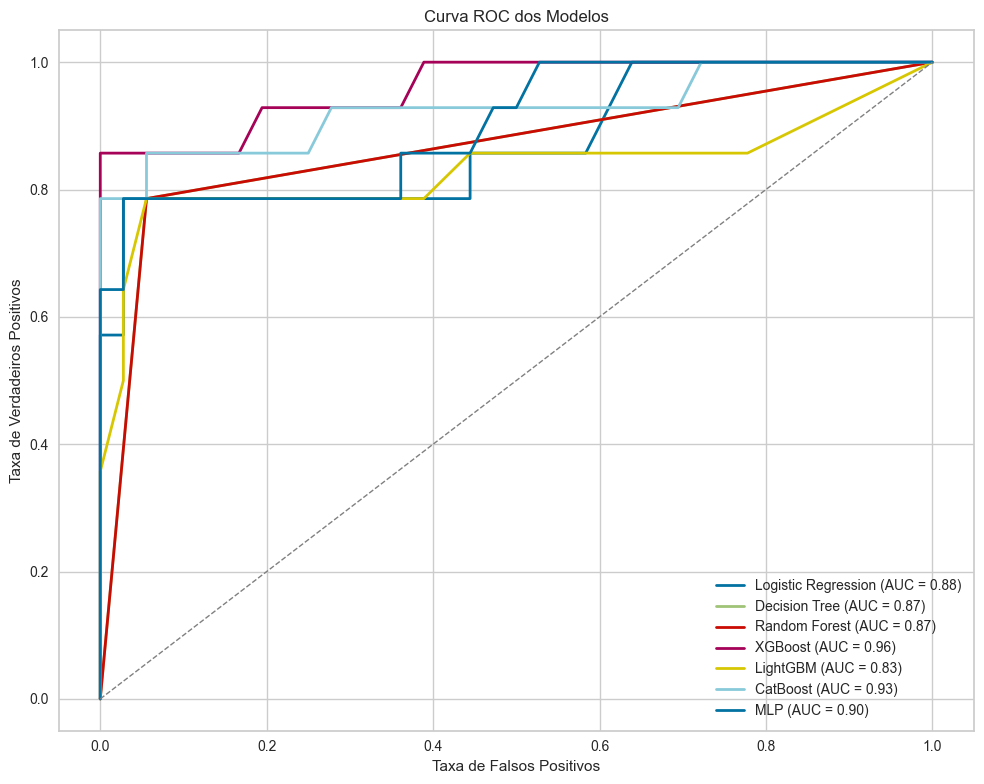

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X_test = get_config('X_test_transformed')
y_test = get_config('y_test_transformed')

plt.figure(figsize=(10, 8))

for name, model in models_dict.items():
    # Extrair o modelo final da pipeline
    final_estimator = model.steps[-1][1]

    # Probabilidade da classe positiva
    y_prob = final_estimator.predict_proba(X_test)[:, 1]

    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)

    # Plotar curva
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.2f})")

# Linha diagonal (baseline)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC dos Modelos")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


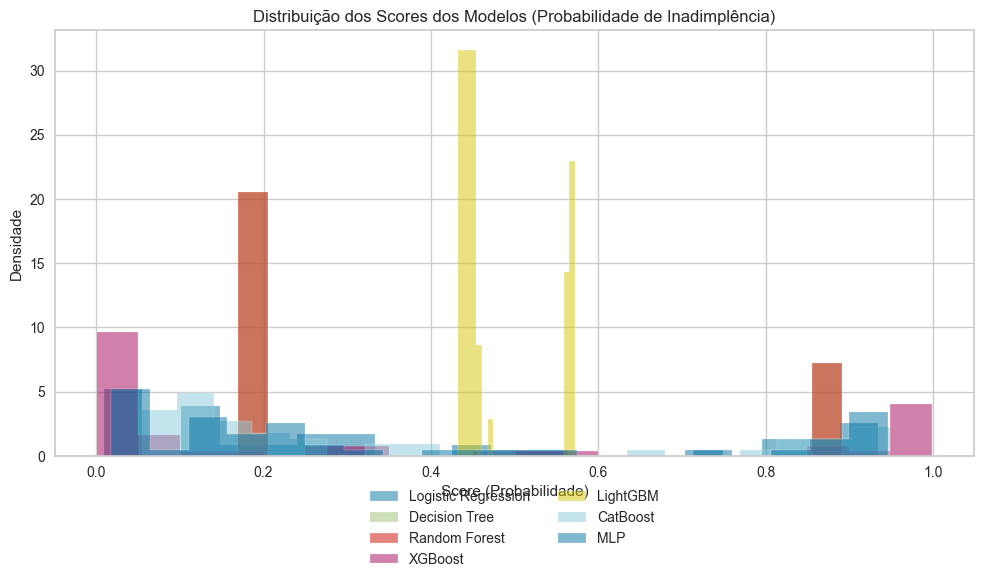

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, model in models_dict.items():
    final_estimator = model.steps[-1][1]
    y_prob = final_estimator.predict_proba(X_test)[:, 1]
    plt.hist(y_prob, bins=20, alpha=0.5, label=name, density=True, histtype='stepfilled')

plt.title('Distribuição dos Scores dos Modelos (Probabilidade de Inadimplência)')
plt.xlabel('Score (Probabilidade)')
plt.ylabel('Densidade')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


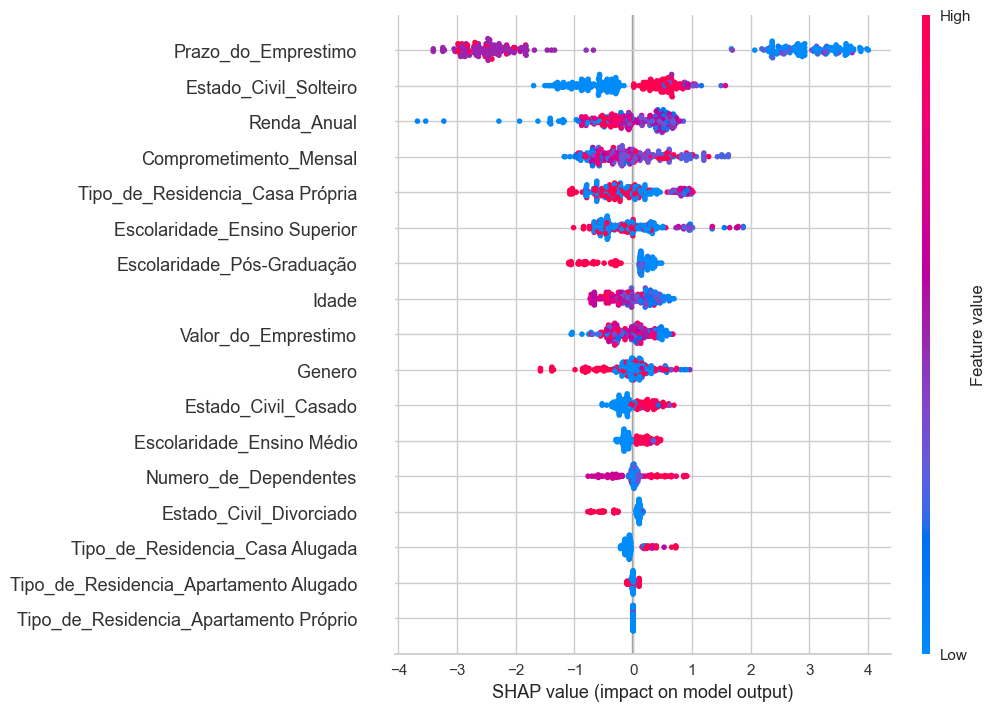

In [46]:
import shap
from pycaret.classification import get_config

# 1. Obter o modelo XGBoost final (a partir do pipeline do PyCaret)
xgb_model_pipeline = models_dict['XGBoost']
xgb_model = xgb_model_pipeline.steps[-1][1]  # extrai apenas o modelo

# 2. Obter os dados transformados (mesmos usados no treinamento)
X_train_transformed = get_config('X_train_transformed')

# 3. Inicializar o SHAP explainer para XGBoost
explainer = shap.Explainer(xgb_model, X_train_transformed)
shap_values = explainer(X_train_transformed)

# 4. Summary Plot (importância média das features)
shap.plots.beeswarm(shap_values, max_display=18)


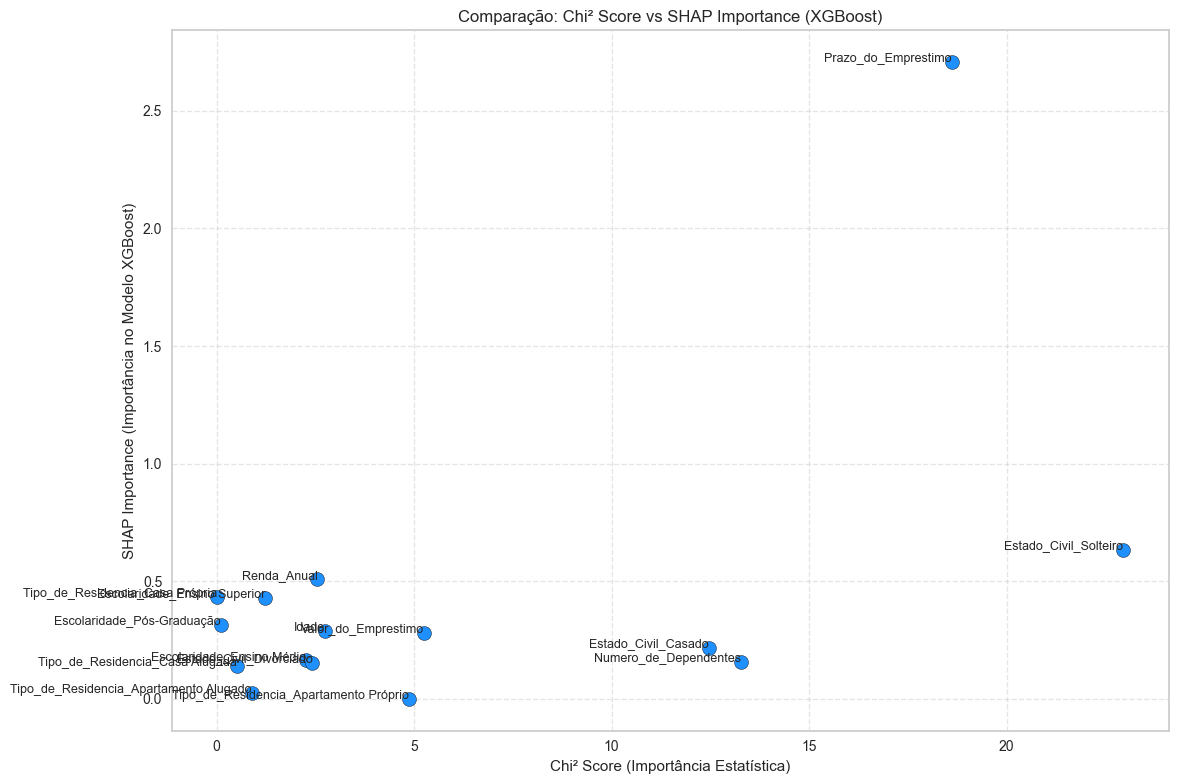

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular a importância média (valor absoluto) de cada feature com SHAP
shap_mean_abs = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'SHAP Importance': shap_mean_abs
})

# 2. Pegar os resultados do chi² já calculado
chi2_df = pd.DataFrame({
    'Feature': feature_analysis['Feature'],
    'Chi² Score': feature_analysis['Chi² Score']
})

# 3. Mesclar os dois resultados pela feature
merged_importance = pd.merge(shap_importance_df, chi2_df, on='Feature')

# 4. Ordenar pelas features com maior SHAP para melhorar visualização
merged_importance = merged_importance.sort_values(by='SHAP Importance', ascending=False)

# 5. Plotar gráfico de dispersão SHAP vs Chi² Score
plt.figure(figsize=(12, 8))
plt.scatter(
    merged_importance['Chi² Score'],
    merged_importance['SHAP Importance'],
    s=100,
    color='dodgerblue',
    edgecolors='black'
)

# Adicionar rótulo das variáveis nos pontos
for i, row in merged_importance.iterrows():
    plt.text(row['Chi² Score'], row['SHAP Importance'], row['Feature'], fontsize=9, ha='right')

plt.xlabel('Chi² Score (Importância Estatística)')
plt.ylabel('SHAP Importance (Importância no Modelo XGBoost)')
plt.title('Comparação: Chi² Score vs SHAP Importance (XGBoost)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Análise Comparativa: Importância Estatística (Chi²) vs Importância no Modelo (SHAP)

O gráfico acima compara duas formas distintas de medir a importância das variáveis:

- **Eixo X (Chi² Score):** mede a relação estatística entre cada variável e a inadimplência com base em testes de independência. Quanto maior o valor, mais relevante é a variável do ponto de vista estatístico.
- **Eixo Y (SHAP Importance):** representa o impacto médio de cada variável na predição do modelo XGBoost. Quanto maior o valor, mais influência a variável teve nas decisões do modelo.

---

### 💡 Principais Insights:

- **Prazo_do_Emprestimo** é **extremamente importante para o modelo**, segundo o SHAP, e também possui um **alto score estatístico**, indicando **forte alinhamento entre estatística e machine learning**.
- **Estado_Civil_Solteiro** aparece com o **maior score no Chi²**, sugerindo forte correlação com inadimplência, mas com impacto moderado nas decisões do modelo — pode indicar que o modelo compensou essa variável com outras correlacionadas.
- Variáveis como **Renda_Anual**, **Valor_do_Emprestimo** e **Idade** aparecem com importância semelhante nos dois eixos, reforçando que são **variáveis consistentes** tanto estatisticamente quanto para o modelo.
- Algumas variáveis (como tipo de residência ou escolaridade) têm **baixa relevância nos dois eixos**, o que sugere que **podem ser menos informativas** para prever inadimplência nesse dataset.

### 🧪 Simulador de Concessão de Crédito com XGBoost

Nesta etapa, desenvolvemos um simulador interativo que permite ao usuário inserir informações de um cliente fictício para prever a **probabilidade de inadimplência** com base no modelo treinado (XGBoost).

Todos os campos relevantes para a análise de crédito podem ser ajustados manualmente — como idade, renda, escolaridade, número de dependentes, etc. O campo **"Comprometimento Mensal"**, por sua vez, **é calculado automaticamente** com base na fórmula:

$$
\text{Comprometimento\ Mensal} = \frac{\frac{\text{Valor\ do\ Empréstimo}}{\text{Prazo\ do\ Empréstimo}}}{\frac{\text{Renda\ Anual}}{12}}
$$

Esse cálculo reflete o percentual da renda mensal comprometida com o pagamento do empréstimo.

Ao clicar no botão **"Prever Inadimplência"**, o simulador:

1. Cria um `DataFrame` com os dados inseridos;
2. Aplica automaticamente o pipeline de pré-processamento utilizado durante o treino do modelo;
3. Executa a previsão com o modelo XGBoost final;
4. Retorna ao usuário:
   - A **probabilidade (%)** de inadimplência;
   - A **classificação binária** (`Adimplente` ou `Inadimplente`).

Essa interface simples torna o modelo acessível a analistas e gestores, permitindo uma **simulação rápida e transparente** de decisões de crédito diretamente no ambiente do notebook.

In [60]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
from pycaret.classification import get_config, predict_model

# Obter o pipeline e o modelo XGBoost final
pipeline = get_config('pipeline')
model = models_dict['XGBoost']

# Criar widgets para entrada dos dados
idade = widgets.IntSlider(description="Idade", min=18, max=100, value=35)
genero = widgets.Dropdown(options=["F", "M"], description="Gênero")
estado_civil = widgets.Dropdown(options=["Solteiro", "Casado", "Divorciado"], description="Estado Civil")
escolaridade = widgets.Dropdown(options=["Ensino Médio", "Ensino Superior", "Pós-Graduação"], description="Escolaridade")
dependentes = widgets.IntSlider(description="Dependentes", min=0, max=10, value=1)
residencia = widgets.Dropdown(
    options=["Casa Própria", "Casa Alugada", "Apartamento Alugado", "Apartamento Próprio"],
    description="Residência"
)
renda_anual = widgets.FloatText(description="Renda Anual (R$)", value=60000.0)
valor_emprestimo = widgets.FloatText(description="Valor do Empréstimo", value=15000.0)
prazo = widgets.IntSlider(description="Prazo (meses)", min=6, max=60, step=6, value=36)

botao = widgets.Button(description="Prever Inadimplência", button_style='success')
output = widgets.Output()

# Função de predição
def ao_clicar(b):
    with output:
        clear_output()
        
        # Calcular Comprometimento_Mensal
        comp = (valor_emprestimo.value / prazo.value) / (renda_anual.value / 12)

        # Montar DataFrame de entrada
        dados_input = pd.DataFrame([{
            'Idade': idade.value,
            'Genero': genero.value,
            'Estado_Civil': estado_civil.value,
            'Escolaridade': escolaridade.value,
            'Numero_de_Dependentes': dependentes.value,
            'Tipo_de_Residencia': residencia.value,
            'Renda_Anual': renda_anual.value,
            'Valor_do_Emprestimo': valor_emprestimo.value,
            'Prazo_do_Emprestimo': prazo.value,
            'Comprometimento_Mensal': comp
        }])

        # Transformar os dados com o pipeline (opcional, apenas para visualizar)
        dados_transformados = pipeline.transform(dados_input)
        colunas = get_config('X_train_transformed').columns
        df_transformado = pd.DataFrame(dados_transformados, columns=colunas)

        # [🔎] Visualizar o input transformado
        print("✅ Dados transformados para predição (após pipeline):")
        display(df_transformado)

        # Prever com pipeline e modelo
        resultado = predict_model(model, data=dados_input)
        score = resultado['prediction_score'][0]
        classe = resultado['prediction_label'][0]

        # Mostrar resultado ao usuário
        print(f"🔮 Confiabilidade do Modelo: {score * 100:.2f}%")
        print(f"📌 Classificação: {'Inadimplente' if classe == 'Sim' else 'Adimplente'}")

# Conectar o botão à função
botao.on_click(ao_clicar)

# Exibir o formulário interativo
display(widgets.VBox([
    idade, genero, estado_civil, escolaridade, dependentes, residencia,
    renda_anual, valor_emprestimo, prazo, botao, output
]))


## 🧠 Estratégias para Otimizar a Concessão de Crédito no Bradesco

Com base na análise dos dados e nos resultados dos modelos de machine learning, propomos **estratégias práticas e escaláveis** para reduzir perdas financeiras e aprimorar as decisões de crédito do Bradesco:

---

### ✅ 1. Implementação de Modelos Preditivos para Inadimplência
- Utilizar o modelo de **XGBoost com explainability via SHAP** para apoiar decisões automáticas ou semiautomáticas.
- Incorporar esse modelo na esteira de concessão para **classificar o risco de cada cliente antes da aprovação**.
- Estabelecer **cutoffs de aprovação baseados no score preditivo** e no perfil de risco histórico.

---

### 📈 2. Criação de Indicadores Derivados (Feature Engineering)
- **Índice de Comprometimento Mensal** (já demonstrado como altamente relevante) deve ser incluído como variável-chave nas decisões.
- Usar outras variáveis derivadas, como:
  - Renda per capita ajustada por dependentes;
  - Tempo médio de relacionamento com o banco (se disponível);
  - Recorrência de solicitações de crédito.

---

### 🧩 3. Estratégias de Segmentação Personalizada
- Criar **políticas de crédito personalizadas por grupo de risco** (ex: solteiros jovens com renda média têm perfil de inadimplência mais elevado).
- Oferecer **limites e prazos ajustados** para clientes de maior risco em vez de negar crédito diretamente.

---

### 🚦 4. Monitoramento Contínuo e Reavaliação de Clientes
- Reavaliar clientes ativos periodicamente com base em modelos preditivos para ajustar limites e condições de crédito.
- Usar o modelo também na **fase de manutenção** para prever deterioração de crédito.

---

### 📊 5. Acompanhamento de Métricas de Performance
- Definir KPIs como:
  - Taxa de inadimplência por segmento;
  - Redução de perdas mensais após uso do modelo;
  - Aumento na eficiência operacional por decisões automatizadas;
  - Acurácia do modelo em produção (drift e revalidação).

---

### 🧱 6. Escalabilidade via APIs e Integrações
- Disponibilizar o modelo em **API com baixo tempo de resposta** para ser integrado ao sistema interno de análise de crédito.
- Usar soluções como **Vertex AI, SageMaker ou PyCaret em batch**, conforme a estrutura do Bradesco.